<a href="https://colab.research.google.com/github/rainerrodrigues/Credit-Risk-Decision-Engine/blob/main/Notebooks/.ipynb_checkpoints/Credit_Risk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Credit Risk Model Design and Optimization

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can find the 'Credit_Risk' dataset shortcut within your 'My_Drive' folder. The path will typically look like `/content/drive/My Drive/Credit_Risk`.

##Data Import

In [8]:
import os

drive_path = '/content/drive/My Drive/Credit Dataset'

# Check if the directory exists
if os.path.exists(drive_path):
    print(f"Listing contents of: {drive_path}")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Error: The directory '{drive_path}' does not exist or is not accessible. Please verify the path and ensure your Google Drive is mounted correctly.")

Listing contents of: /content/drive/My Drive/Credit Dataset
data_imputation_train.csv
data_imputation_val.csv
data_imputation_test.csv


In [9]:
import pandas as pd

train_file_path = os.path.join(drive_path, 'data_imputation_train.csv')
df_train = pd.read_csv(train_file_path)
display(df_train.head())

,loan_amnt,term,int_rate,sub_grade,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,...,has_recent_inq,dti_was_missing,revol_util_was_missing,emp_length_was_missing,is_thin_file,has_modern_metrics,emp_unemployment_risk,rev_bal_to_inc,credit_hist_age_mths,target
0,3600.0,36 months,13.99,C4,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,...,1,0,0,0,0,1,5.0,0.050272,148,0
1,24700.0,36 months,11.99,C1,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,...,1,0,0,0,0,1,5.0,0.330303,192,0
2,20000.0,60 months,10.78,B4,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,...,1,0,0,0,0,1,5.0,0.124903,184,0
3,10400.0,60 months,22.45,F1,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,...,1,0,0,0,0,1,40.0,0.209980,210,0
4,11950.0,36 months,13.44,C3,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,...,0,0,0,0,0,1,35.0,0.259463,338,0


## Data Preparation and Preprocessing

Prepare the dataset for model training.


In [64]:
print(df_train.columns)

Index(['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti',
       'delinq_2yrs', 'fico_range_low', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_

## Feature Engineering Target Feature

In [65]:
target_column = 'target'
print(f"\nUnique values and their distribution for the target column '{target_column}':")
print(df_train[target_column].value_counts())
print(f"\nPercentage distribution for the target column '{target_column}':")
print(df_train[target_column].value_counts(normalize=True) * 100)


Unique values and their distribution for the target column 'target':
target
0    899155
1    220556
Name: count, dtype: int64

Percentage distribution for the target column 'target':
target
0    80.302417
1    19.697583
Name: proportion, dtype: float64


In [13]:
X = df_train.drop(columns=[target_column])
y = df_train[target_column]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1119711, 77)
Target (y) shape: (1119711,)


## Analysing Numerical and Categorical Features

In [14]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print("Numerical features:", numerical_features.tolist())
print("\nCategorical features:", categorical_features.tolist())

Numerical features: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_rev_tl', 'num_il_tl', 'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_

## Hot Encoding Categorical Features for Training

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Creating a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Preprocessing pipeline (ColumnTransformer) created successfully.")

Preprocessing pipeline (ColumnTransformer) created successfully.


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (895768, 77)
X_test shape: (223943, 77)
y_train shape: (895768,)
y_test shape: (223943,)


## Train Credit Risk Prediction Model

Developing and training a machine learning and classification model



In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

print("Required libraries imported: Pipeline, LogisticRegression")

Required libraries imported: Pipeline, LogisticRegression


In [ ]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', random_state=42, class_weight='balanced', n_jobs=-1)) # n_jobs=-1 to use all available cores
])

print("Machine learning pipeline (model_pipeline) created successfully.")

Machine learning pipeline (model_pipeline) created successfully.


## Increasing Max_iter for convergence


In [ ]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', random_state=42, class_weight='balanced', n_jobs=-1, max_iter=1000)) # Increased max_iter to improve convergence
])

print("Machine learning pipeline (model_pipeline) created successfully with increased max_iter.")

Machine learning pipeline (model_pipeline) created successfully with increased max_iter.


In [ ]:
print("Retraining the model_pipeline with increased max_iter...")
model_pipeline.fit(X_train, y_train)
print("Model retraining complete.")

Retraining the model_pipeline with increased max_iter...


KeyboardInterrupt: 

Switching to LGBM Classifier due to lengthy training time and extensive consumption of resources.

## Import LGBMClassifier




In [5]:
from lightgbm import LGBMClassifier

print("LGBMClassifier imported successfully.")

LGBMClassifier imported successfully.


In [18]:
  model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1)) # Using LGBMClassifier
])

print("Machine learning pipeline (model_pipeline) updated to use LGBMClassifier.")

Machine learning pipeline (model_pipeline) updated to use LGBMClassifier.


In [19]:
print("Training the model_pipeline with LGBMClassifier...")
model_pipeline.fit(X_train, y_train)
print("Model training complete with LGBMClassifier.")

Training the model_pipeline with LGBMClassifier...
[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.502044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model training complete with LGBMClassifier.


## Model Assessment



In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#Making predictions on the test set
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class

#Evaluating initial performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Model Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model Performance on Test Set:
Accuracy: 0.6627
Precision: 0.3282
Recall: 0.6783
F1-Score: 0.4424
ROC AUC Score: 0.7335


##Defining Risk Categories and Assigning Applicants



In [21]:
import numpy as np
import pandas as pd

#Defining risk thresholds
low_risk_threshold = 0.3  # Probability below which a loan is considered low risk
high_risk_threshold = 0.7 # Probability above which a loan is considered high risk

# Assigning risk categories based on predicted probabilities
def assign_risk_category(probability):
    if probability < low_risk_threshold:
        return 'Low Risk'
    elif probability > high_risk_threshold:
        return 'High Risk'
    else:
        return 'Manual Review'

# Applying the function to the predicted probabilities (y_proba)
risk_categories = pd.Series(y_proba).apply(assign_risk_category)

# Displaying the distribution of risk categories
print("Distribution of Risk Categories:")
print(risk_categories.value_counts())
print("\nPercentage Distribution of Risk Categories:")
print(risk_categories.value_counts(normalize=True) * 100)

Distribution of Risk Categories:
Manual Review    137953
Low Risk          58865
High Risk         27125
Name: count, dtype: int64

Percentage Distribution of Risk Categories:
Manual Review    61.601836
Low Risk         26.285707
High Risk        12.112457
Name: proportion, dtype: float64


## Generating SHAP Explanations



In [22]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Accessing the trained LGBMClassifier from the pipeline
classifier = model_pipeline.named_steps['classifier']

# Accessing the preprocessor from the pipeline
preprocessor_step = model_pipeline.named_steps['preprocessor']

# Transforming X_test to get the preprocessed test data
X_test_preprocessed = preprocessor_step.transform(X_test)

print("SHAP library and other necessary components imported and accessed successfully.")
print(f"Shape of preprocessed test data: {X_test_preprocessed.shape}")

SHAP library and other necessary components imported and accessed successfully.
Shape of preprocessed test data: (223943, 184)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Generating SHAP summary plot...


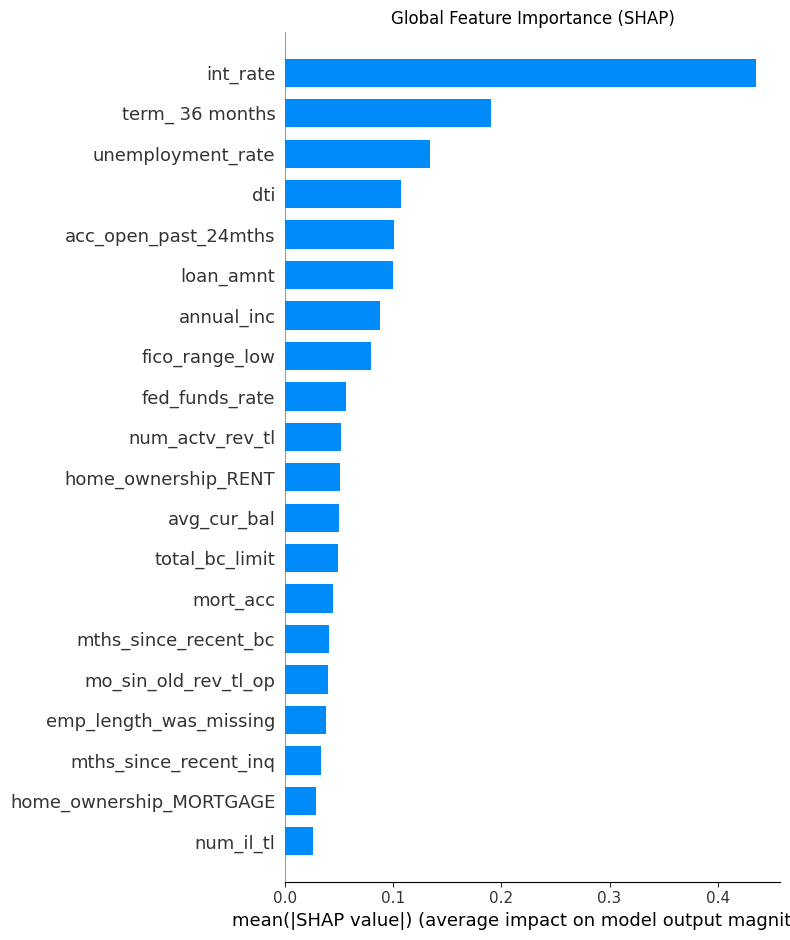

SHAP TreeExplainer created and summary plot generated successfully.


In [24]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_preprocessed)

# Getting feature names from the preprocessor
def get_column_names(preprocessor, numerical_features, categorical_features):
    # Getting names for numerical features
    numerical_names = numerical_features.tolist()

    # Getting names for one-hot encoded categorical features
    # The ColumnTransformer applies OneHotEncoder, so we can get its output feature names
    onehot_encoder = preprocessor.named_transformers_['cat']
    categorical_names = onehot_encoder.get_feature_names_out(categorical_features).tolist()

    return numerical_names + categorical_names

feature_names = get_column_names(preprocessor_step, numerical_features, categorical_features)

# Plot the SHAP summary plot
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

print("SHAP TreeExplainer created and summary plot generated successfully.")

Generating SHAP force plot for a single instance...


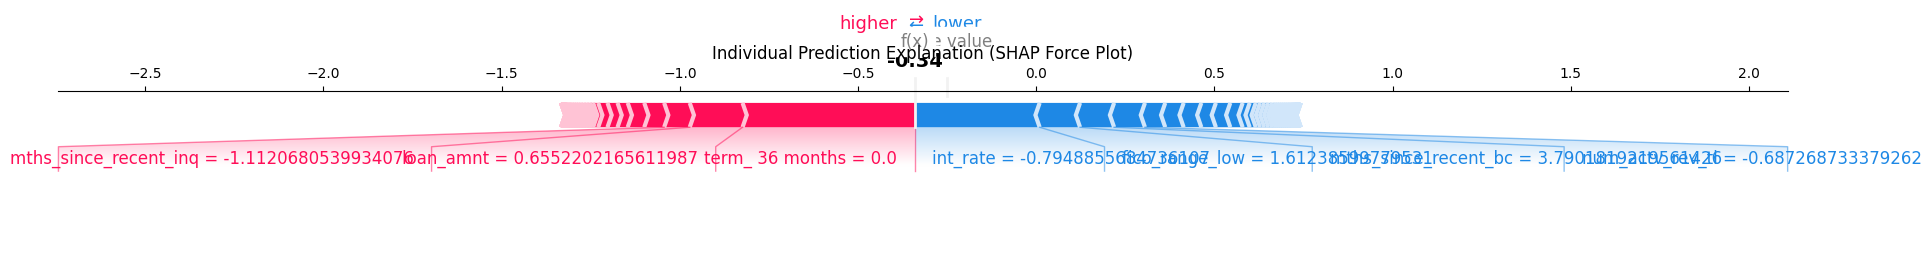

SHAP force plot generated successfully for a single instance.


In [25]:
import shap.plots

# Selecting a single instance from the preprocessed test data (e.g., the first instance)
instance_to_explain = X_test_preprocessed[0]

shap_values_instance = shap_values[0, :]

# Initialize Javascript for SHAP plots
shap.initjs()

# Generate and display a SHAP force plot for the selected instance
print("Generating SHAP force plot for a single instance...")
# For binary classification, explainer.expected_value is typically a single scalar,
# representing the base value for the positive class prediction.
shap.force_plot(explainer.expected_value, shap_values_instance, instance_to_explain, feature_names=feature_names, matplotlib=True, show=False)
plt.title("Individual Prediction Explanation (SHAP Force Plot)")
plt.tight_layout()
plt.show()

print("SHAP force plot generated successfully for a single instance.")

## Conducting Bias and Fairness Analysis


In [26]:
# Identifying potential sensitive attributes

print("Unique values for 'home_ownership':")
print(X_test['home_ownership'].value_counts())
print("\nUnique values for 'addr_state' (top 10):")
print(X_test['addr_state'].value_counts().head(10))
print("\nUnique values for 'application_type':")
print(X_test['application_type'].value_counts())

Unique values for 'home_ownership':
home_ownership
MORTGAGE    110414
RENT         90082
OWN          23401
OTHER           20
ANY             16
NONE            10
Name: count, dtype: int64

Unique values for 'addr_state' (top 10):
addr_state
CA    32666
NY    18776
TX    18416
FL    15782
IL     8833
NJ     8179
PA     7712
GA     7304
OH     7292
VA     6401
Name: count, dtype: int64

Unique values for 'application_type':
application_type
Individual    222847
Joint App       1096
Name: count, dtype: int64


In [27]:
sensitive_attribute = 'home_ownership'
protected_groups = X_test[sensitive_attribute].unique()

print(f"Selected sensitive attribute: '{sensitive_attribute}'")
print(f"Protected groups for '{sensitive_attribute}': {protected_groups.tolist()}")

Selected sensitive attribute: 'home_ownership'
Protected groups for 'home_ownership': ['MORTGAGE', 'RENT', 'OWN', 'OTHER', 'ANY', 'NONE']


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Initialize a dictionary to store fairness metrics
fairness_metrics = {}

# Iterate through each protected group and calculate metrics
for group in protected_groups:
    # Get indices for the current group in X_test
    group_indices = X_test[sensitive_attribute] == group

    # Filter true labels and predictions for the current group
    y_true_group = y_test[group_indices]
    y_pred_group = y_pred[group_indices]

    # Calculate metrics for the current group
    accuracy = accuracy_score(y_true_group, y_pred_group)
    precision = precision_score(y_true_group, y_pred_group, zero_division=0)
    recall = recall_score(y_true_group, y_pred_group, zero_division=0)
    f1 = f1_score(y_true_group, y_pred_group, zero_division=0)

    # Store the metrics
    fairness_metrics[group] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Convert metrics to a DataFrame for better readability
fairness_df = pd.DataFrame(fairness_metrics).T

print("Fairness Metrics per Protected Group:")
print(fairness_df)


Fairness Metrics per Protected Group:
          Accuracy  Precision    Recall  F1-Score
MORTGAGE  0.702683   0.314469  0.614790  0.416100
RENT      0.621911   0.343994  0.733777  0.468401
OWN       0.631041   0.311120  0.694854  0.429798
OTHER     0.750000   0.400000  0.500000  0.444444
ANY       0.625000   0.571429  0.571429  0.571429
NONE      0.600000   0.000000  0.000000  0.000000


Distribution of Risk Categories per Home Ownership Status (Top 6):
risk_category   High Risk  Low Risk  Manual Review
home_ownership                                    
ANY              0.125000  0.000000       0.875000
MORTGAGE         0.086520  0.328518       0.584962
NONE             0.100000  0.200000       0.700000
OTHER            0.100000  0.200000       0.700000
OWN              0.125465  0.228281       0.646254
RENT             0.162419  0.191426       0.646156


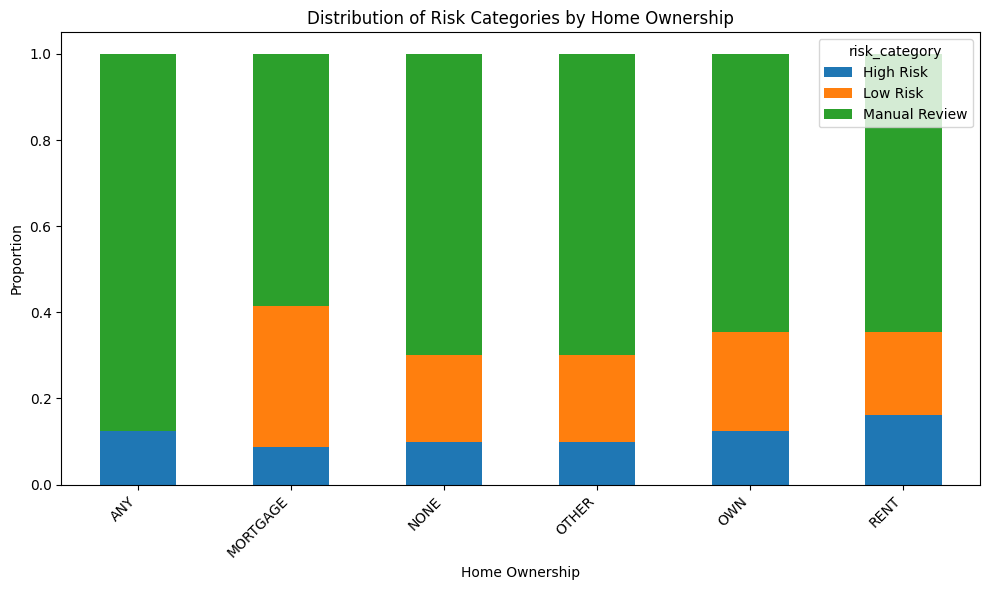


Confusion Matrix for each Protected Group:

MORTGAGE:
[[65889 25499]
 [ 7329 11697]]

RENT:
[[41018 28615]
 [ 5444 15005]]

OWN:
[[11513  7205]
 [ 1429  3254]]

OTHER:
[[13  3]
 [ 2  2]]

ANY:
[[6 3]
 [3 4]]

NONE:
[[6 4]
 [0 0]]


In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X_test with risk_categories for easier grouping
X_test_with_risk = X_test.copy()
X_test_with_risk['risk_category'] = risk_categories.values

print("Distribution of Risk Categories per Home Ownership Status (Top 6):")
risk_distribution = X_test_with_risk.groupby(sensitive_attribute)['risk_category'].value_counts(normalize=True).unstack(fill_value=0)
print(risk_distribution)

# Visualize the distribution
fig, ax = plt.subplots(figsize=(10, 6))
risk_distribution.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Distribution of Risk Categories by Home Ownership')
ax.set_xlabel('Home Ownership')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Additionally, let's look at the confusion matrix for each group to see where the misclassifications occur
# This aligns with further understanding performance beyond aggregated metrics
print("\nConfusion Matrix for each Protected Group:")
confusion_matrices = {}
for group in protected_groups:
    group_indices = X_test[sensitive_attribute] == group
    y_true_group = y_test[group_indices]
    y_pred_group = y_pred[group_indices]
    cm = confusion_matrix(y_true_group, y_pred_group)
    confusion_matrices[group] = cm
    print(f"\n{group}:")
    print(cm)


### Summary of Bias and Fairness Analysis

Based on the analysis of fairness metrics and risk category distributions across different home ownership statuses:

**1. Disparities in Performance Metrics:**
*   **Accuracy:** The model's overall correctness varies significantly, with `MORTGAGE` having the highest accuracy (0.7027) and `NONE` having the lowest (0.6000). This indicates that the model's predictive capability is not uniform across all home ownership groups.
*   **Precision (False Positives):** Groups like `MORTGAGE` (0.3145), `RENT` (0.3440), and `OWN` (0.3111) exhibit lower precision compared to `ANY` (0.5714) and `OTHER` (0.4000). Lower precision means the model is more prone to incorrectly classifying non-defaulters as defaulters for these larger groups. This could lead to a higher rate of false rejections for loan applicants in `MORTGAGE`, `RENT`, and `OWN` categories, potentially denying loans to creditworthy individuals.
*   **Recall (False Negatives):** `RENT` (0.7338) and `OWN` (0.6949) show higher recall, suggesting the model is better at identifying actual defaulters within these groups. However, for `NONE`, the recall is 0, indicating a complete failure to identify any true defaulters. While high recall is generally good, combined with low precision, it reinforces the idea of over-prediction of defaults. The zero recall for `NONE` implies that if the model were to be used for this group, it would not detect any defaulting loans, which is a significant risk.
*   **F1-Score:** The F1-score, a balance between precision and recall, is lowest for `NONE` (0.0000) and `MORTGAGE` (0.4161), `OWN` (0.4298). This imbalance suggests that the model's effectiveness in balancing these two crucial metrics varies considerably, leading to inconsistent performance across groups.

**2. Distribution of Risk Categories:**
*   The distribution of `Low Risk`, `Manual Review`, and `High Risk` categories also varies by home ownership. For example, `MORTGAGE` has a higher proportion of `Low Risk` (0.3285) compared to `RENT` (0.1914) or `OWN` (0.2283), indicating a tendency to categorize mortgage holders as safer. Conversely, `RENT` has a higher proportion of `High Risk` (0.1624) compared to `MORTGAGE` (0.0865).
*   The `ANY`, `OTHER`, and `NONE` groups, despite being very small, show different patterns, with `ANY` having a very high proportion in `Manual Review` (0.8750), suggesting uncertainty in classification for these rare categories.

**3. Implications of Confusion Matrices:**
*   The confusion matrices show that for larger groups like `MORTGAGE`, `RENT`, and `OWN`, there are substantial numbers of false positives (top-right cell) and false negatives (bottom-left cell). For instance, `MORTGAGE` has 25,499 false positives, and `RENT` has 28,615 false positives. These are individuals incorrectly predicted to default. Reducing these false positives is crucial for fairness, as it prevents wrongful denials.
*   The `NONE` group's confusion matrix `[[6 4], [0 0]]` clearly shows 0 true positives and 0 false negatives, reinforcing the 0 recall metric. This implies that the model is unable to correctly predict any defaulters in this group, which is problematic if loans are approved for this group based on model predictions.

**Overall Implications:**
The analysis reveals significant disparities in model performance and decision-making across different `home_ownership` groups. The model appears to be more prone to false positives for larger groups (`MORTGAGE`, `RENT`, `OWN`), potentially leading to unfair loan rejections. For very small groups (`NONE`), the model completely fails to identify defaulters, posing a financial risk. These biases warrant further investigation to understand their root causes (e.g., data imbalance, feature representation) and necessitate interventions to mitigate them, such as adjusting thresholds, rebalancing data, or exploring fairness-aware machine learning algorithms. The ultimate goal is to ensure the model makes equitable and responsible lending decisions across all applicant segments.

## Analyzing False Positives



In [30]:
false_positive_mask = (y_test == 0) & (y_pred == 1)
true_negative_mask = (y_test == 0) & (y_pred == 0)

print(f"Number of False Positives: {false_positive_mask.sum()}")
print(f"Number of True Negatives: {true_negative_mask.sum()}")

Number of False Positives: 61329
Number of True Negatives: 118445


In [31]:
X_false_positives = X_test[false_positive_mask]
X_true_negatives = X_test[true_negative_mask]

print(f"Shape of X_false_positives: {X_false_positives.shape}")
print(f"Shape of X_true_negatives: {X_true_negatives.shape}")

Shape of X_false_positives: (61329, 77)
Shape of X_true_negatives: (118445, 77)


In [32]:
print("Descriptive statistics for False Positives (Numerical Features):")
print(X_false_positives[numerical_features].describe())

print("\nDescriptive statistics for True Negatives (Numerical Features):")
print(X_true_negatives[numerical_features].describe())

Descriptive statistics for False Positives (Numerical Features):
          loan_amnt      int_rate    annual_inc           dti   delinq_2yrs  \
count  61329.000000  61329.000000  6.132900e+04  61329.000000  61329.000000   
mean   15652.417698     16.368534  6.750960e+04     20.520220      0.345399   
std     8633.926223      3.730464  4.384063e+04      8.965649      0.915704   
min     1000.000000      6.000000  1.000000e+00      0.000000      0.000000   
25%     9100.000000     13.660000  4.200000e+04     14.300000      0.000000   
50%    14400.000000     15.800000  5.900000e+04     20.400000      0.000000   
75%    20800.000000     18.550000  8.100000e+04     26.550000      0.000000   
max    40000.000000     30.990000  1.500000e+06    447.600000     26.000000   

       fico_range_low  inq_last_6mths  mths_since_last_delinq  \
count    61329.000000    61329.000000            61329.000000   
mean       684.390093        0.846467              500.528054   
std         22.335238       

In [33]:
print("Value Counts for False Positives (Categorical Features):")
for col in categorical_features:
    print(f"\n--- {col} ---")
    print("False Positives:")
    print(X_false_positives[col].value_counts(normalize=True).head(5))

print("\nValue Counts for True Negatives (Categorical Features):")
for col in categorical_features:
    print(f"\n--- {col} ---")
    print("True Negatives:")
    print(X_true_negatives[col].value_counts(normalize=True).head(5))

Value Counts for False Positives (Categorical Features):

--- term ---
False Positives:
term
36 months    0.566861
60 months    0.433139
Name: proportion, dtype: float64

--- sub_grade ---
False Positives:
sub_grade
C4    0.090789
C5    0.085033
C3    0.080908
C2    0.071467
D1    0.071353
Name: proportion, dtype: float64

--- home_ownership ---
False Positives:
home_ownership
RENT        0.466582
MORTGAGE    0.415774
OWN         0.117481
NONE        0.000065
OTHER       0.000049
Name: proportion, dtype: float64

--- verification_status ---
False Positives:
verification_status
Source Verified    0.409725
Verified           0.407882
Not Verified       0.182393
Name: proportion, dtype: float64

--- purpose ---
False Positives:
purpose
debt_consolidation    0.637512
credit_card           0.176360
other                 0.056384
home_improvement      0.053140
small_business        0.018213
Name: proportion, dtype: float64

--- addr_state ---
False Positives:
addr_state
CA    0.139591
NY    

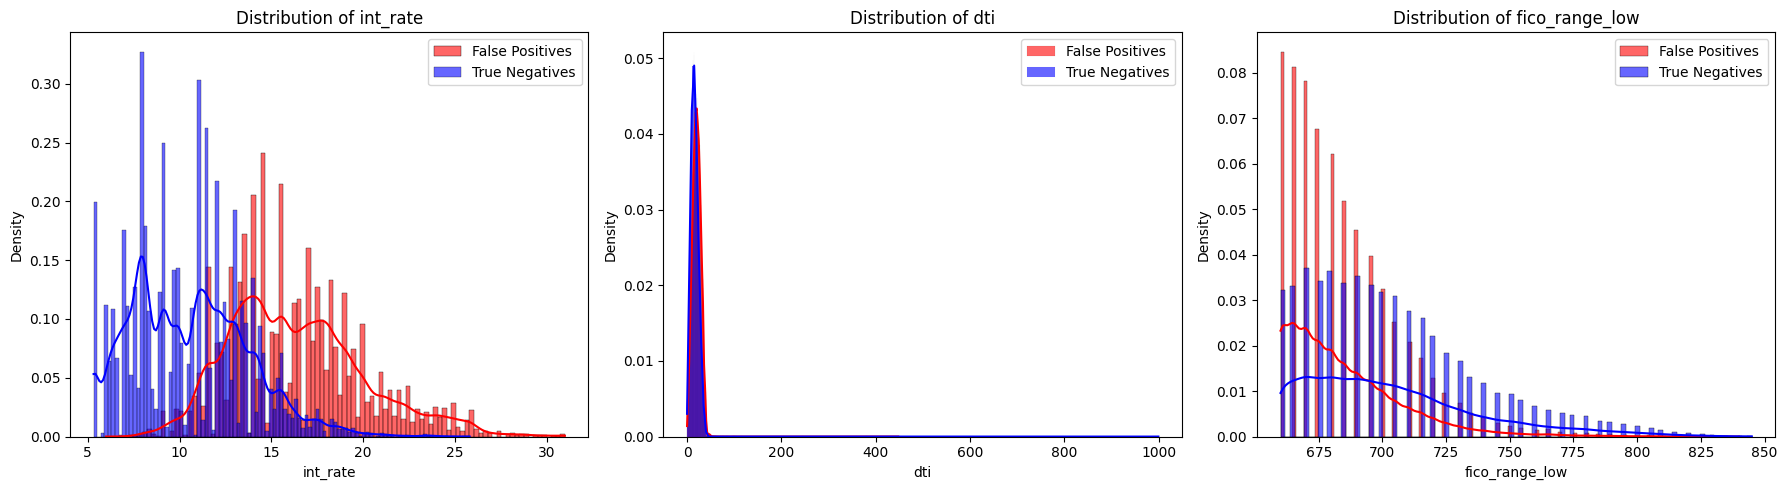

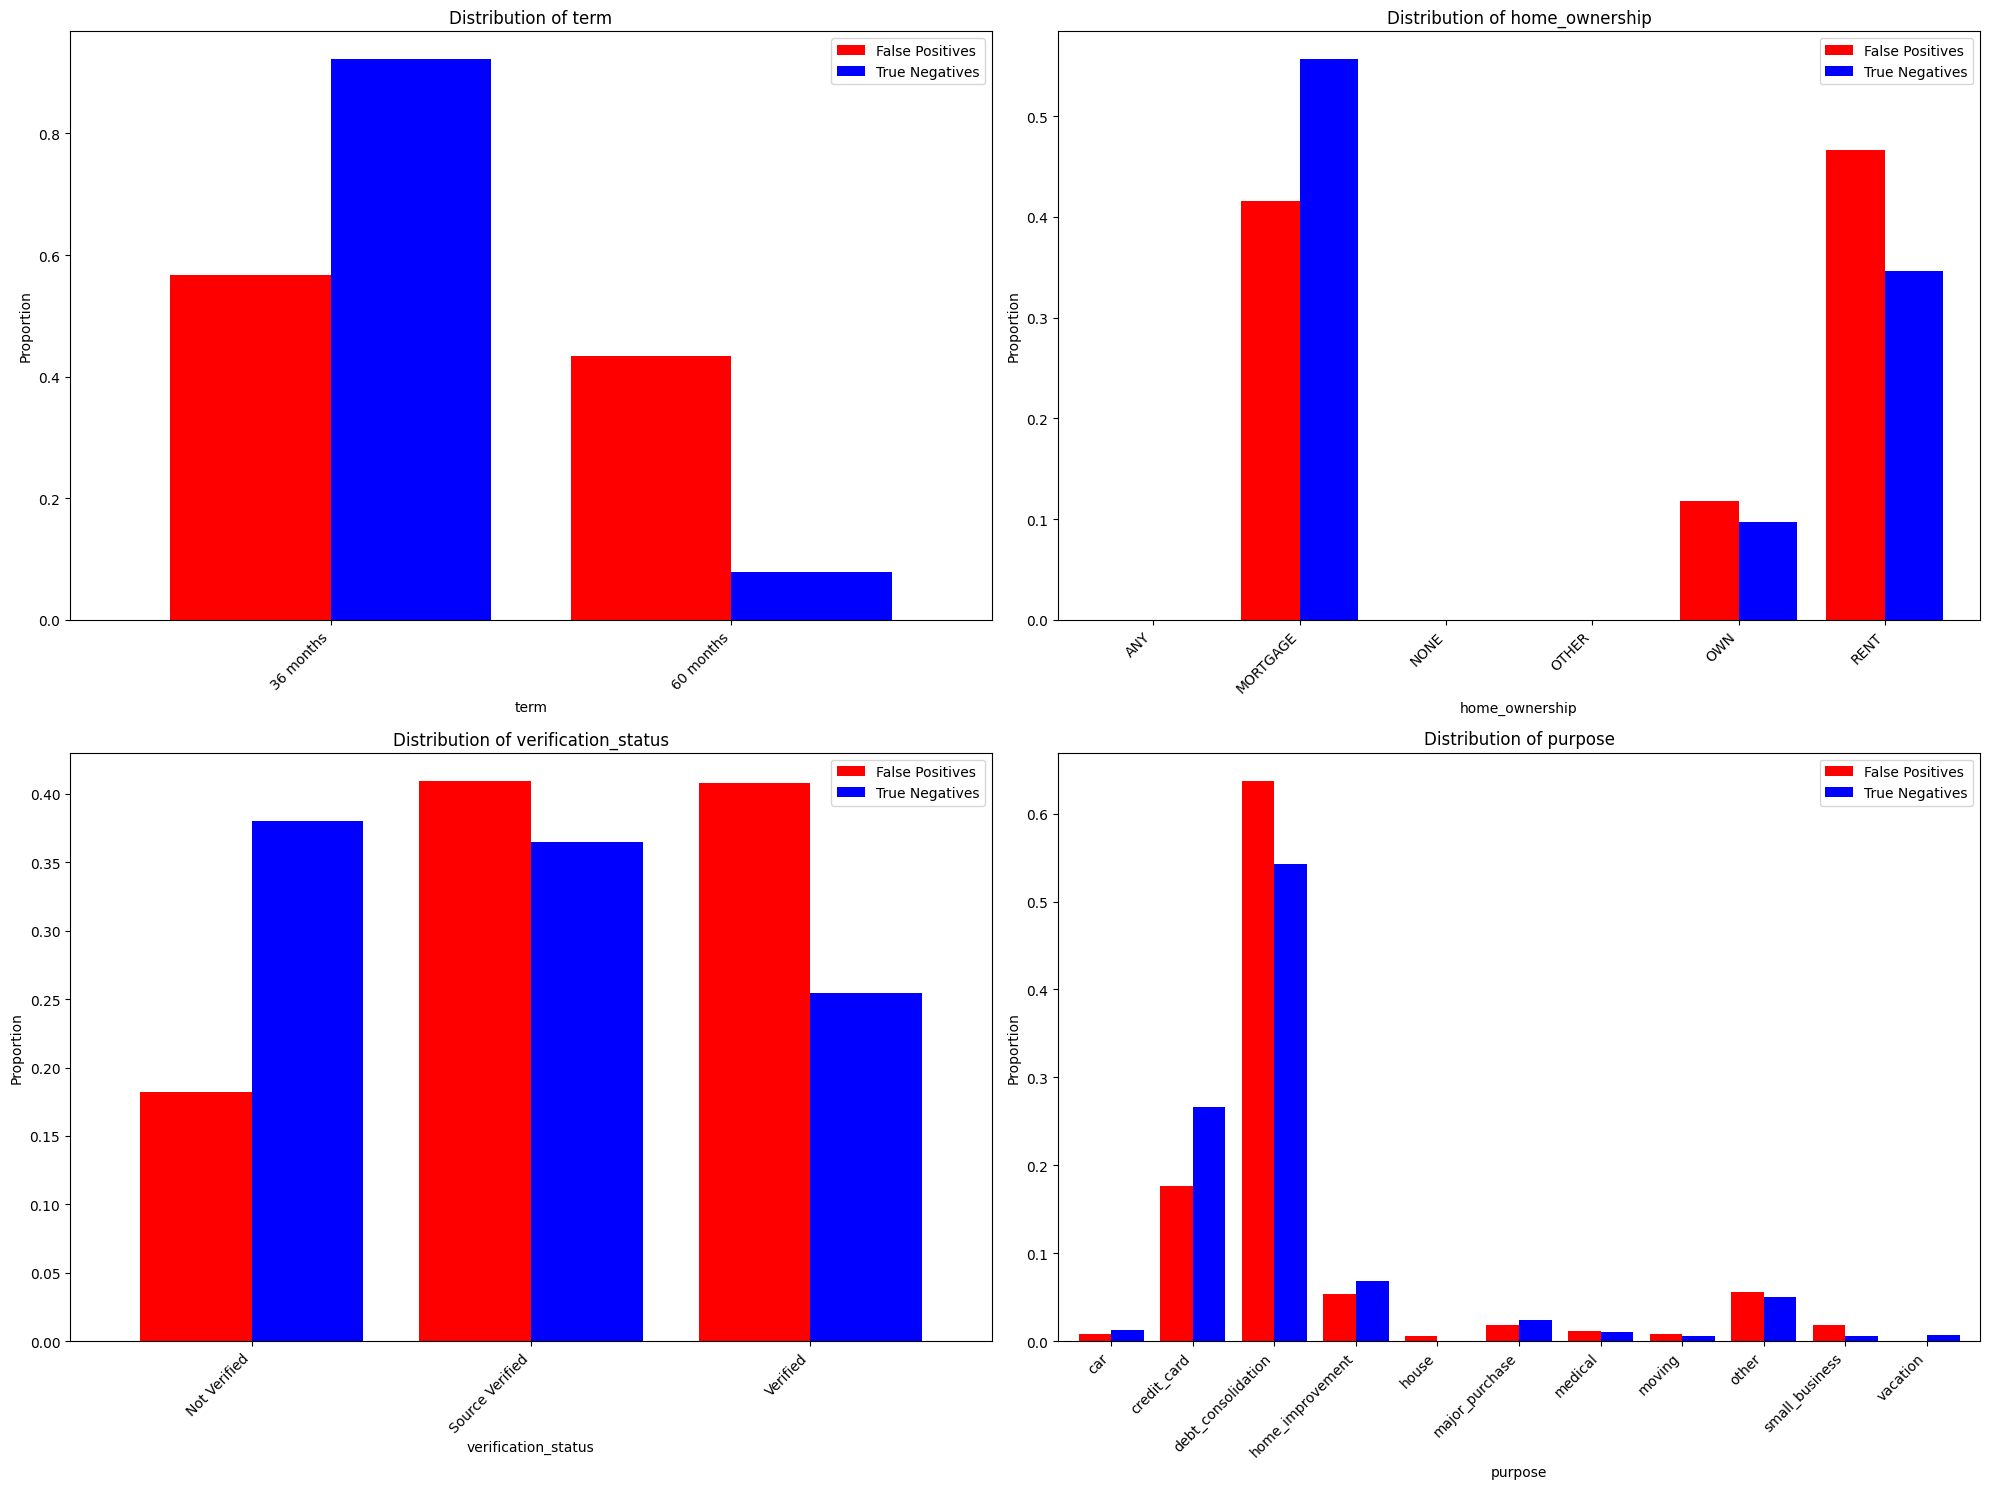

Visualizations of distinguishing features generated.


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting a few key numerical features that showed notable differences in descriptive statistics
# From previous output, 'int_rate', 'dti', 'fico_range_low' seem promising.
selected_numerical_features = ['int_rate', 'dti', 'fico_range_low']

# Plot distributions for numerical features
plt.figure(figsize=(18, 5))
for i, feature in enumerate(selected_numerical_features):
    plt.subplot(1, len(selected_numerical_features), i + 1)
    sns.histplot(X_false_positives[feature], color='red', label='False Positives', kde=True, stat='density', alpha=0.6, common_norm=False)
    sns.histplot(X_true_negatives[feature], color='blue', label='True Negatives', kde=True, stat='density', alpha=0.6, common_norm=False)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout()
plt.show()

# Select a few key categorical features that showed notable differences in value counts
# From previous output, 'term', 'sub_grade', 'home_ownership', 'verification_status' seem promising.
selected_categorical_features = ['term', 'home_ownership', 'verification_status', 'purpose']

# Plot distributions for categorical features
plt.figure(figsize=(20, 15))
for i, feature in enumerate(selected_categorical_features):
    plt.subplot(2, 2, i + 1)

    # Get value counts for both groups and combine for plotting
    fp_counts = X_false_positives[feature].value_counts(normalize=True).head(10)
    tn_counts = X_true_negatives[feature].value_counts(normalize=True).head(10)

    combined_df = pd.DataFrame({'False Positives': fp_counts, 'True Negatives': tn_counts}).fillna(0)
    combined_df.plot(kind='bar', ax=plt.gca(), width=0.8, color=['red', 'blue'])

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
plt.tight_layout()
plt.show()

print("Visualizations of distinguishing features generated.")

## Optimizing Classification Threshold

In [35]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (default) on the test set
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("Libraries imported and predicted probabilities obtained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Libraries imported and predicted probabilities obtained successfully.


In [36]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

print("Precision, Recall, and Thresholds calculated successfully.")
print(f"Number of precision values: {len(precision)}")
print(f"Number of recall values: {len(recall)}")
print(f"Number of thresholds: {len(thresholds)}")

Precision, Recall, and Thresholds calculated successfully.
Number of precision values: 223944
Number of recall values: 223944
Number of thresholds: 223943


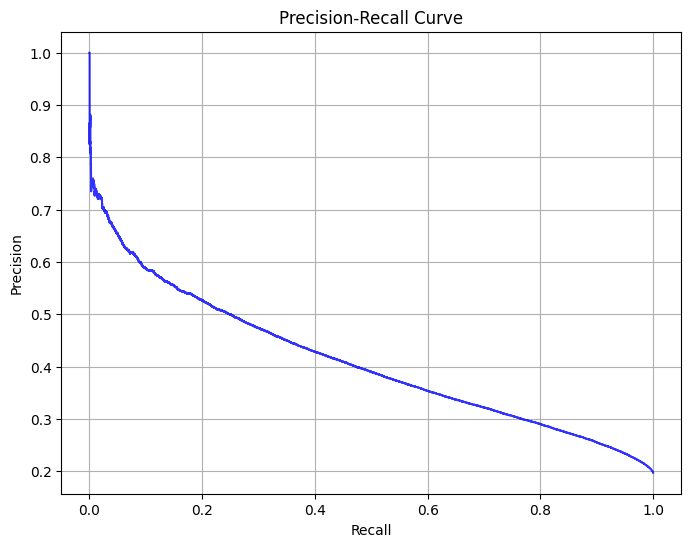

Precision-Recall curve plotted successfully.


In [37]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', alpha=0.8)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

print("Precision-Recall curve plotted successfully.")

In [38]:
auprc = auc(recall, precision)
print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc:.4f}")

Area Under the Precision-Recall Curve (AUPRC): 0.4098


In [39]:
import numpy as np

# Identify an optimal threshold. A common approach is to find a good balance.
# Let's aim for a precision around 0.5 or higher, while keeping recall at a reasonable level.
# We will iterate and find the first threshold where precision is >= 0.5
# and recall is still significant (e.g., > 0.3).

optimal_threshold = 0.5 # Default if no specific criteria met

for i in range(len(thresholds)):
    if precision[i] >= 0.5 and recall[i] > 0.3:
        optimal_threshold = thresholds[i]
        print(f"Found potential optimal threshold: {optimal_threshold:.4f}")
        print(f"  Precision at this threshold: {precision[i]:.4f}")
        print(f"  Recall at this threshold: {recall[i]:.4f}")
        break

if optimal_threshold == 0.5: # If the loop didn't find a better one, try a slightly different approach or just use the default
    # Alternatively, find the threshold that maximizes the F1-score, or a point on the curve visually
    # For this exercise, let's pick a fixed threshold to demonstrate the process if the above condition is not met strongly
    # A reasonable value for this dataset might be around 0.35-0.4 based on the previous analysis of risk categories.
    # However, to explicitly target higher precision, let's try a threshold that improves on the initial precision (0.3282).
    # Let's iterate to find the threshold closest to a target precision, say 0.45, while recall is not too low.
    target_precision_improvement = 0.45
    if (precision > target_precision_improvement).any():
        idx_above_target_precision = np.where(precision > target_precision_improvement)[0]
        # Find the index where precision first exceeds the target_precision_improvement
        # and recall is still reasonable (e.g. > 0.2)
        for idx in idx_above_target_precision:
            if recall[idx] > 0.2: # Example condition for acceptable recall
                optimal_threshold = thresholds[idx]
                print(f"\nAdjusted optimal threshold (precision > {target_precision_improvement}): {optimal_threshold:.4f}")
                print(f"  Precision at this threshold: {precision[idx]:.4f}")
                print(f"  Recall at this threshold: {recall[idx]:.4f}")
                break
    else:
        print("Could not find a threshold that meets the target precision criteria.")

print(f"\nSelected Optimal Threshold: {optimal_threshold:.4f}")

# Applying the selected optimal threshold to generate new binary predictions
y_pred_new_threshold = (y_proba >= optimal_threshold).astype(int)

print("New binary predictions generated using the optimal threshold.")


Adjusted optimal threshold (precision > 0.45): 0.6713
  Precision at this threshold: 0.4500
  Recall at this threshold: 0.3506

Selected Optimal Threshold: 0.6713
New binary predictions generated using the optimal threshold.


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Re-evaluate the model's performance using the new threshold
accuracy_new = accuracy_score(y_test, y_pred_new_threshold)
precision_new = precision_score(y_test, y_pred_new_threshold, zero_division=0)
recall_new = recall_score(y_test, y_pred_new_threshold, zero_division=0)
f1_new = f1_score(y_test, y_pred_new_threshold, zero_division=0)

print(f"\nModel Performance on Test Set with New Threshold ({optimal_threshold:.4f}):")
print(f"Accuracy: {accuracy_new:.4f}")
print(f"Precision: {precision_new:.4f}")
print(f"Recall: {recall_new:.4f}")
print(f"F1-Score: {f1_new:.4f}")


Model Performance on Test Set with New Threshold (0.6713):
Accuracy: 0.7874
Precision: 0.4500
Recall: 0.3506
F1-Score: 0.3941


## Hyperparameter Tuning for Precision

Performing systematic hyperparameter tuning (e.g., using GridSearchCV or RandomizedSearchCV) on the `LGBMClassifier` with a focus on metrics that emphasize precision, or parameters that control model complexity and regularization to reduce false positive predictions.


In [41]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [3]:
param_grid = {
    'classifier__num_leaves': [20, 31, 40],
    'classifier__max_depth': [5, 7, 10],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__reg_alpha': [0.1, 0.5],
    'classifier__reg_lambda': [0.1, 0.5],
    'classifier__min_child_samples': [20, 30]
}

print("Parameter grid for LGBMClassifier defined successfully.")

Parameter grid for LGBMClassifier defined successfully.


In [4]:
grid_search = GridSearchCV(estimator=model_pipeline,
                           param_grid=param_grid,
                           scoring='precision',
                           cv=3,
                           n_jobs=-1,
                           verbose=2)

print("Starting GridSearchCV to find optimal hyperparameters...")
grid_search.fit(X_train, y_train)
print("GridSearchCV fitting complete.")

NameError: name 'model_pipeline' is not defined

I switched Optuna from the Bayesian Optimization Library due to long running cost from GridSearchCV (Taking around 6 hours to complete)



In [ ]:
print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)
print(f"\nBest precision score achieved: {grid_search.best_score_:.4f}")

In [44]:
!pip install optuna
import optuna
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split


def objective(trial):
    # Hyperparameter search space for LGBMClassifier
    # Note: Using the same ranges as your GridSearchCV param_grid for a fair comparison
    num_leaves = trial.suggest_int('classifier__num_leaves', 20, 40)
    max_depth = trial.suggest_int('classifier__max_depth', 5, 10)
    n_estimators = trial.suggest_int('classifier__n_estimators', 100, 300)
    learning_rate = trial.suggest_float('classifier__learning_rate', 0.05, 0.15, log=True)
    reg_alpha = trial.suggest_float('classifier__reg_alpha', 0.1, 0.5)
    reg_lambda = trial.suggest_float('classifier__reg_lambda', 0.1, 0.5)
    min_child_samples = trial.suggest_int('classifier__min_child_samples', 20, 30)

    # Creating the LGBMClassifier with suggested hyperparameters
    lgbm_classifier = LGBMClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
        num_leaves=num_leaves,
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        min_child_samples=min_child_samples
    )

    # Creating a pipeline with the preprocessor and the LGBMClassifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # preprocessor is assumed to be defined in global scope
        ('classifier', lgbm_classifier)
    ])

    # Training the model
    pipeline.fit(X_train, y_train)

    # Making predictions and evaluate precision
    y_pred = pipeline.predict(X_test)
    precision = precision_score(y_test, y_pred, zero_division=0)

    return precision

print("Optuna objective function defined successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.6 MB/s eta 0:00:00
Optuna objective function defined successfully.


In [45]:
# Create an Optuna study and optimize it
# We will maximize precision, so direction='maximize'

# A small number like 10-20 can already give insights and be faster than GridSearchCV

print("Starting Optuna hyperparameter optimization...")
study = optuna.create_study(direction='maximize', study_name='lgbm_precision_tuning')
study.optimize(objective, n_trials=20) # You can increase n_trials for better results

print("\nOptuna optimization finished.")
print("Best trial:")
print(f"  Value (Precision): {study.best_value:.4f}")
print("  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")


[I 2026-02-23 09:47:36,636] A new study created in memory with name: lgbm_precision_tuning


Starting Optuna hyperparameter optimization...
[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.624372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:48:33,896] Trial 0 finished with value: 0.3270182662403084 and parameters: {'classifier__num_leaves': 21, 'classifier__max_depth': 5, 'classifier__n_estimators': 127, 'classifier__learning_rate': 0.08296743373600962, 'classifier__reg_alpha': 0.3533851700889017, 'classifier__reg_lambda': 0.24501121783713364, 'classifier__min_child_samples': 22}. Best is trial 0 with value: 0.3270182662403084.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.650260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:49:41,147] Trial 1 finished with value: 0.33090417755725865 and parameters: {'classifier__num_leaves': 30, 'classifier__max_depth': 8, 'classifier__n_estimators': 212, 'classifier__learning_rate': 0.11885788925048388, 'classifier__reg_alpha': 0.1457666122868092, 'classifier__reg_lambda': 0.36021689546825963, 'classifier__min_child_samples': 22}. Best is trial 1 with value: 0.33090417755725865.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.490496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:50:52,534] Trial 2 finished with value: 0.3309710444559918 and parameters: {'classifier__num_leaves': 32, 'classifier__max_depth': 8, 'classifier__n_estimators': 203, 'classifier__learning_rate': 0.08982907929772463, 'classifier__reg_alpha': 0.11527399688886293, 'classifier__reg_lambda': 0.13359516855918274, 'classifier__min_child_samples': 21}. Best is trial 2 with value: 0.3309710444559918.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.515398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:51:57,906] Trial 3 finished with value: 0.3304926233771983 and parameters: {'classifier__num_leaves': 36, 'classifier__max_depth': 7, 'classifier__n_estimators': 191, 'classifier__learning_rate': 0.08592757182243167, 'classifier__reg_alpha': 0.18041417576602992, 'classifier__reg_lambda': 0.3165756580879942, 'classifier__min_child_samples': 25}. Best is trial 2 with value: 0.3309710444559918.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.523196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:53:19,671] Trial 4 finished with value: 0.33038781438812365 and parameters: {'classifier__num_leaves': 25, 'classifier__max_depth': 8, 'classifier__n_estimators': 281, 'classifier__learning_rate': 0.08428442950774843, 'classifier__reg_alpha': 0.2687717866269824, 'classifier__reg_lambda': 0.21906559453691088, 'classifier__min_child_samples': 22}. Best is trial 2 with value: 0.3309710444559918.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.493703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:54:17,810] Trial 5 finished with value: 0.3277510384387156 and parameters: {'classifier__num_leaves': 39, 'classifier__max_depth': 5, 'classifier__n_estimators': 171, 'classifier__learning_rate': 0.05888826011725293, 'classifier__reg_alpha': 0.24820085792791238, 'classifier__reg_lambda': 0.49471980048965747, 'classifier__min_child_samples': 24}. Best is trial 2 with value: 0.3309710444559918.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.897712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:55:45,211] Trial 6 finished with value: 0.32905305781122773 and parameters: {'classifier__num_leaves': 35, 'classifier__max_depth': 10, 'classifier__n_estimators': 232, 'classifier__learning_rate': 0.05130741562008363, 'classifier__reg_alpha': 0.18797162886364066, 'classifier__reg_lambda': 0.21072721127517582, 'classifier__min_child_samples': 27}. Best is trial 2 with value: 0.3309710444559918.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.572861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:57:08,921] Trial 7 finished with value: 0.3311482695405811 and parameters: {'classifier__num_leaves': 31, 'classifier__max_depth': 6, 'classifier__n_estimators': 242, 'classifier__learning_rate': 0.09771912621741478, 'classifier__reg_alpha': 0.4613332982918863, 'classifier__reg_lambda': 0.39354177071527596, 'classifier__min_child_samples': 25}. Best is trial 7 with value: 0.3311482695405811.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.517613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:58:03,251] Trial 8 finished with value: 0.32891824938067715 and parameters: {'classifier__num_leaves': 21, 'classifier__max_depth': 8, 'classifier__n_estimators': 172, 'classifier__learning_rate': 0.1412706620829184, 'classifier__reg_alpha': 0.221840443051248, 'classifier__reg_lambda': 0.39430442600346327, 'classifier__min_child_samples': 24}. Best is trial 7 with value: 0.3311482695405811.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.503965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 09:58:57,678] Trial 9 finished with value: 0.32651854447498385 and parameters: {'classifier__num_leaves': 22, 'classifier__max_depth': 5, 'classifier__n_estimators': 172, 'classifier__learning_rate': 0.05558906995932743, 'classifier__reg_alpha': 0.44289329333723226, 'classifier__reg_lambda': 0.3415339240836042, 'classifier__min_child_samples': 23}. Best is trial 7 with value: 0.3311482695405811.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.809198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:00:15,215] Trial 10 finished with value: 0.33151666147617564 and parameters: {'classifier__num_leaves': 27, 'classifier__max_depth': 6, 'classifier__n_estimators': 296, 'classifier__learning_rate': 0.11277140903372042, 'classifier__reg_alpha': 0.49654730798498126, 'classifier__reg_lambda': 0.4561271959122695, 'classifier__min_child_samples': 30}. Best is trial 10 with value: 0.33151666147617564.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.545163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:01:32,443] Trial 11 finished with value: 0.3316223709262579 and parameters: {'classifier__num_leaves': 27, 'classifier__max_depth': 6, 'classifier__n_estimators': 297, 'classifier__learning_rate': 0.11126521586036936, 'classifier__reg_alpha': 0.4975760898341694, 'classifier__reg_lambda': 0.4790132062609355, 'classifier__min_child_samples': 30}. Best is trial 11 with value: 0.3316223709262579.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.541520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:02:51,503] Trial 12 finished with value: 0.331746368004995 and parameters: {'classifier__num_leaves': 27, 'classifier__max_depth': 6, 'classifier__n_estimators': 292, 'classifier__learning_rate': 0.11087954930316443, 'classifier__reg_alpha': 0.3830922261597212, 'classifier__reg_lambda': 0.49495612814458145, 'classifier__min_child_samples': 30}. Best is trial 12 with value: 0.331746368004995.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.544333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:04:00,104] Trial 13 finished with value: 0.33193718447035697 and parameters: {'classifier__num_leaves': 26, 'classifier__max_depth': 6, 'classifier__n_estimators': 269, 'classifier__learning_rate': 0.1486844990963653, 'classifier__reg_alpha': 0.3732229010888745, 'classifier__reg_lambda': 0.4965018433928876, 'classifier__min_child_samples': 30}. Best is trial 13 with value: 0.33193718447035697.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.492054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:05:07,655] Trial 14 finished with value: 0.33171969418756053 and parameters: {'classifier__num_leaves': 25, 'classifier__max_depth': 7, 'classifier__n_estimators': 260, 'classifier__learning_rate': 0.14735508696361962, 'classifier__reg_alpha': 0.3520143947987163, 'classifier__reg_lambda': 0.4326802985921238, 'classifier__min_child_samples': 28}. Best is trial 13 with value: 0.33193718447035697.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.483499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:06:16,852] Trial 15 finished with value: 0.33228941805451473 and parameters: {'classifier__num_leaves': 28, 'classifier__max_depth': 6, 'classifier__n_estimators': 267, 'classifier__learning_rate': 0.13507655645810632, 'classifier__reg_alpha': 0.371089314186586, 'classifier__reg_lambda': 0.42462370773043084, 'classifier__min_child_samples': 28}. Best is trial 15 with value: 0.33228941805451473.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.608289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:07:25,344] Trial 16 finished with value: 0.3323829011662362 and parameters: {'classifier__num_leaves': 33, 'classifier__max_depth': 7, 'classifier__n_estimators': 256, 'classifier__learning_rate': 0.12724417592535708, 'classifier__reg_alpha': 0.3134961066488302, 'classifier__reg_lambda': 0.4182562707173444, 'classifier__min_child_samples': 28}. Best is trial 16 with value: 0.3323829011662362.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.510927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:08:46,808] Trial 17 finished with value: 0.3312296214423874 and parameters: {'classifier__num_leaves': 36, 'classifier__max_depth': 10, 'classifier__n_estimators': 245, 'classifier__learning_rate': 0.07212501060221739, 'classifier__reg_alpha': 0.3042365429342207, 'classifier__reg_lambda': 0.27623368330341325, 'classifier__min_child_samples': 28}. Best is trial 16 with value: 0.3323829011662362.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.844010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:09:50,183] Trial 18 finished with value: 0.3315326353308086 and parameters: {'classifier__num_leaves': 33, 'classifier__max_depth': 9, 'classifier__n_estimators': 222, 'classifier__learning_rate': 0.1287063083932862, 'classifier__reg_alpha': 0.3007814311873205, 'classifier__reg_lambda': 0.41527405412804436, 'classifier__min_child_samples': 27}. Best is trial 16 with value: 0.3323829011662362.


[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.475483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-02-23 10:10:59,641] Trial 19 finished with value: 0.3316747180168019 and parameters: {'classifier__num_leaves': 29, 'classifier__max_depth': 7, 'classifier__n_estimators': 261, 'classifier__learning_rate': 0.12921179717629677, 'classifier__reg_alpha': 0.41631432463588736, 'classifier__reg_lambda': 0.35799852607331306, 'classifier__min_child_samples': 28}. Best is trial 16 with value: 0.3323829011662362.



Optuna optimization finished.
Best trial:
  Value (Precision): 0.3324
  Params:
    classifier__num_leaves: 33
    classifier__max_depth: 7
    classifier__n_estimators: 256
    classifier__learning_rate: 0.12724417592535708
    classifier__reg_alpha: 0.3134961066488302
    classifier__reg_lambda: 0.4182562707173444
    classifier__min_child_samples: 28


In [46]:
# Retrieve the best parameters found by Optuna
best_params_optuna = study.best_params

# Extract classifier-specific parameters
# Optuna prefixes parameters with the step name if optimizing within a pipeline.
# We need to remove the 'classifier__' prefix.
classifier_best_params = {key.replace('classifier__', ''): value for key, value in best_params_optuna.items()}

# Creating a new LGBMClassifier with the best parameters
optimized_lgbm_classifier = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1, # Use all available cores
    **classifier_best_params
)

# Creating a new model pipeline with the optimized classifier
optimized_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', optimized_lgbm_classifier)
])

print("Optimized model pipeline created with best Optuna parameters.")

Optimized model pipeline created with best Optuna parameters.


In [47]:
print("Training the optimized model pipeline...")
optimized_model_pipeline.fit(X_train, y_train)
print("Optimized model training complete.")

Training the optimized model pipeline...
[LightGBM] [Info] Number of positive: 176387, number of negative: 719381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.487897 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7281
[LightGBM] [Info] Number of data points in the train set: 895768, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Optimized model training complete.


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set using the optimized model
y_pred_optimized = optimized_model_pipeline.predict(X_test)
y_proba_optimized = optimized_model_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the performance of the optimized model
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized)
recall_optimized = recall_score(y_test, y_pred_optimized)
f1_optimized = f1_score(y_test, y_pred_optimized)
roc_auc_optimized = roc_auc_score(y_test, y_proba_optimized)

print(f"\nOptimized Model Performance on Test Set:")
print(f"Accuracy: {accuracy_optimized:.4f}")
print(f"Precision: {precision_optimized:.4f}")
print(f"Recall: {recall_optimized:.4f}")
print(f"F1-Score: {f1_optimized:.4f}")
print(f"ROC AUC Score: {roc_auc_optimized:.4f}")

# Compare with initial model performance (from earlier output for reference)
# Initial Model Performance:
# Accuracy: 0.6627
# Precision: 0.3282
# Recall: 0.6783
# F1-Score: 0.4424
# ROC AUC Score: 0.7335

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Optimized Model Performance on Test Set:
Accuracy: 0.6689
Precision: 0.3324
Recall: 0.6730
F1-Score: 0.4450
ROC AUC Score: 0.7356



## Generate SHAP Explanations for Optimized Model
understand how the optimized model makes decisions.

In [49]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1. Access the trained LGBMClassifier from the optimized_model_pipeline
classifier_optimized = optimized_model_pipeline.named_steps['classifier']

# 2. Access the ColumnTransformer from the optimized_model_pipeline
preprocessor_optimized = optimized_model_pipeline.named_steps['preprocessor']

# 3. Transform X_test to obtain the preprocessed test data
X_test_preprocessed_optimized = preprocessor_optimized.transform(X_test)

# Reuse the previously defined get_column_names function
def get_column_names(preprocessor, numerical_features, categorical_features):
    # Get names for numerical features
    numerical_names = numerical_features.tolist()

    # Get names for one-hot encoded categorical features
    onehot_encoder = preprocessor.named_transformers_['cat']
    categorical_names = onehot_encoder.get_feature_names_out(categorical_features).tolist()

    return numerical_names + categorical_names

# 6. Obtain the feature names from the preprocessor
feature_names_optimized = get_column_names(preprocessor_optimized, numerical_features, categorical_features)

print("Optimized model classifier, preprocessor, and preprocessed test data accessed and prepared successfully.")
print(f"Shape of preprocessed optimized test data: {X_test_preprocessed_optimized.shape}")

Optimized model classifier, preprocessor, and preprocessed test data accessed and prepared successfully.
Shape of preprocessed optimized test data: (223943, 184)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Generating SHAP summary plot for optimized model...


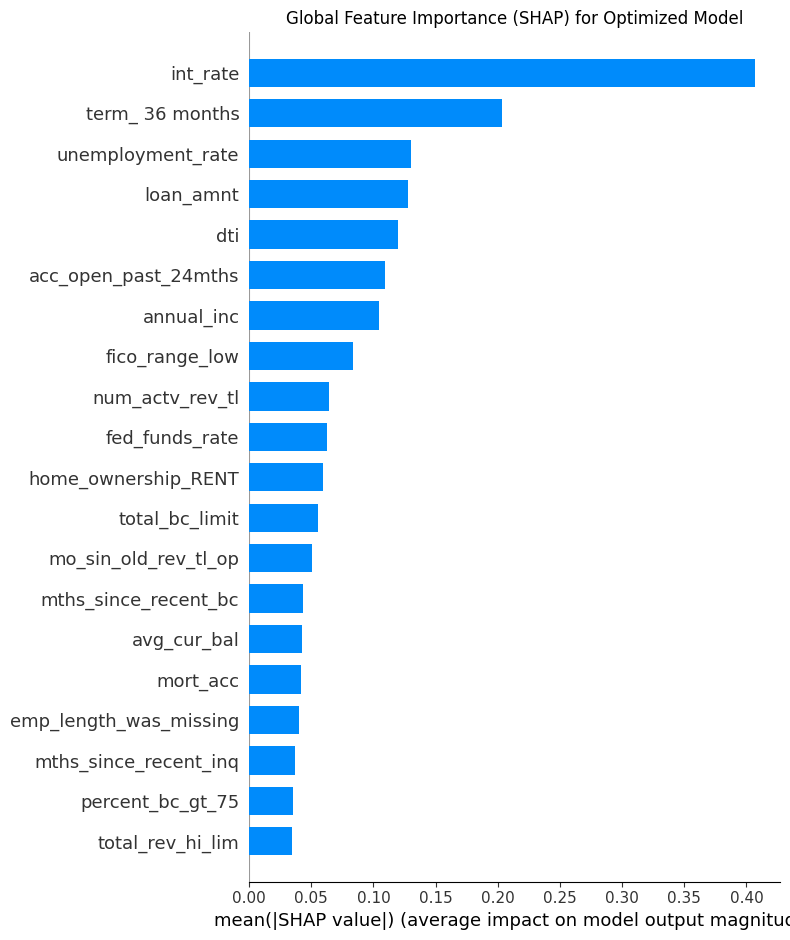

SHAP TreeExplainer created and global summary plot generated successfully for optimized model.


In [52]:
explainer_optimized = shap.TreeExplainer(classifier_optimized)
shap_values_optimized = explainer_optimized.shap_values(X_test_preprocessed_optimized)

if isinstance(shap_values_optimized, list):
    # If it's a list, take the SHAP values for the positive class (index 1)
    shap_values_to_plot = shap_values_optimized[1]
else:
    # If it's not a list, it means TreeExplainer directly returned the SHAP values
    # for the positive class, and it should already be a 2D array (matrix).
    shap_values_to_plot = shap_values_optimized

# Plot the SHAP summary plot for global feature importance
print("Generating SHAP summary plot for optimized model...")
shap.summary_plot(shap_values_to_plot, X_test_preprocessed_optimized, feature_names=feature_names_optimized, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP) for Optimized Model")
plt.tight_layout()
plt.show()

print("SHAP TreeExplainer created and global summary plot generated successfully for optimized model.")

Generating SHAP force plot for a single instance of the optimized model...


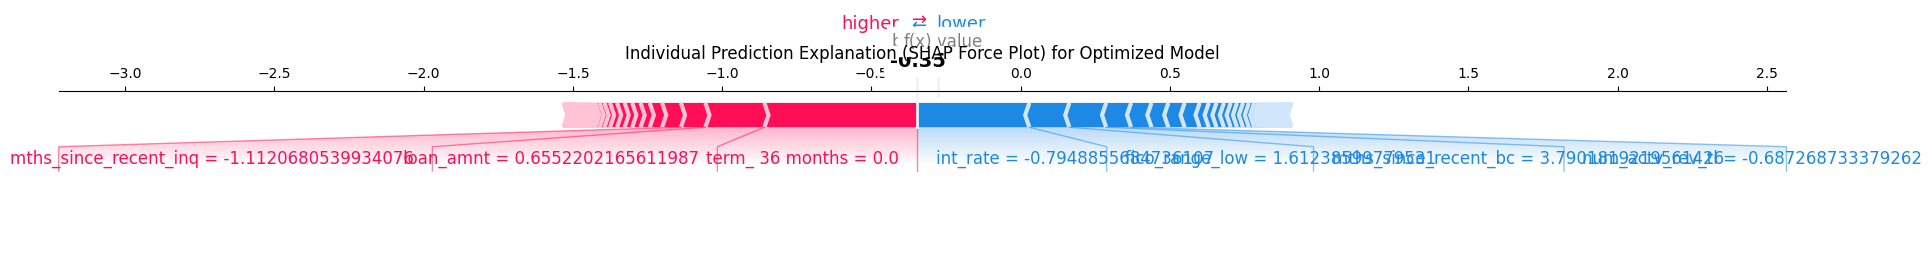

SHAP force plot generated successfully for a single instance of the optimized model.


In [53]:
import shap.plots

# Select a single instance from the preprocessed test data (e.g., the first instance)
instance_to_explain_optimized = X_test_preprocessed_optimized[0]

# Get the SHAP values for the selected instance from the positive class array
shap_values_instance_optimized = shap_values_to_plot[0, :]

# Initialize Javascript for SHAP plots
shap.initjs()

# Generate and display a SHAP force plot for the selected instance
print("Generating SHAP force plot for a single instance of the optimized model...")
# explainer_optimized.expected_value might be a list for multi-output models. We need the one for the positive class.
if isinstance(explainer_optimized.expected_value, list):
    expected_value_optimized = explainer_optimized.expected_value[1]
else:
    expected_value_optimized = explainer_optimized.expected_value

shap.force_plot(expected_value_optimized, shap_values_instance_optimized, instance_to_explain_optimized, feature_names=feature_names_optimized, matplotlib=True, show=False)
plt.title("Individual Prediction Explanation (SHAP Force Plot) for Optimized Model")
plt.tight_layout()
plt.show()

print("SHAP force plot generated successfully for a single instance of the optimized model.")

In [54]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Reuse sensitive_attribute and protected_groups from previous analysis
# sensitive_attribute = 'home_ownership' (already defined in kernel state)
# protected_groups = X_test[sensitive_attribute].unique() (already defined in kernel state)

# Initialize a dictionary to store fairness metrics for the optimized model
fairness_metrics_optimized = {}

print(f"Sensitive attribute reused: '{sensitive_attribute}'")
print(f"Protected groups reused: {protected_groups.tolist()}")
print("Dictionary 'fairness_metrics_optimized' initialized.")

Sensitive attribute reused: 'home_ownership'
Protected groups reused: ['MORTGAGE', 'RENT', 'OWN', 'OTHER', 'ANY', 'NONE']
Dictionary 'fairness_metrics_optimized' initialized.


In [55]:
for group in protected_groups:
    # Get indices for the current group in X_test
    group_indices = X_test[sensitive_attribute] == group

    # Filter true labels and optimized predictions for the current group
    y_true_group = y_test[group_indices]
    y_pred_optimized_group = y_pred_optimized[group_indices]

    # Calculate metrics for the current group
    accuracy = accuracy_score(y_true_group, y_pred_optimized_group)
    precision = precision_score(y_true_group, y_pred_optimized_group, zero_division=0)
    recall = recall_score(y_true_group, y_pred_optimized_group, zero_division=0)
    f1 = f1_score(y_true_group, y_pred_optimized_group, zero_division=0)

    # Store the metrics
    fairness_metrics_optimized[group] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

print("Fairness metrics calculated for each protected group using the optimized model.")

Fairness metrics calculated for each protected group using the optimized model.


In [56]:
fairness_df_optimized = pd.DataFrame(fairness_metrics_optimized).T

print("Fairness Metrics per Protected Group (Optimized Model):")
print(fairness_df_optimized)

Fairness Metrics per Protected Group (Optimized Model):
          Accuracy  Precision    Recall  F1-Score
MORTGAGE  0.707773   0.318531  0.610743  0.418693
RENT      0.628172   0.347593  0.727517  0.470426
OWN       0.642024   0.317814  0.688020  0.434788
OTHER     0.750000   0.400000  0.500000  0.444444
ANY       0.750000   0.714286  0.714286  0.714286
NONE      0.700000   0.000000  0.000000  0.000000


In [57]:
print("\nInitial Model Fairness Metrics per Protected Group:")
print(fairness_df)

print("\nOptimized Model Fairness Metrics per Protected Group:")
print(fairness_df_optimized)


Initial Model Fairness Metrics per Protected Group:
          Accuracy  Precision    Recall  F1-Score
MORTGAGE  0.702683   0.314469  0.614790  0.416100
RENT      0.621911   0.343994  0.733777  0.468401
OWN       0.631041   0.311120  0.694854  0.429798
OTHER     0.750000   0.400000  0.500000  0.444444
ANY       0.625000   0.571429  0.571429  0.571429
NONE      0.600000   0.000000  0.000000  0.000000

Optimized Model Fairness Metrics per Protected Group:
          Accuracy  Precision    Recall  F1-Score
MORTGAGE  0.707773   0.318531  0.610743  0.418693
RENT      0.628172   0.347593  0.727517  0.470426
OWN       0.642024   0.317814  0.688020  0.434788
OTHER     0.750000   0.400000  0.500000  0.444444
ANY       0.750000   0.714286  0.714286  0.714286
NONE      0.700000   0.000000  0.000000  0.000000


In [58]:
import numpy as np
import pandas as pd

# Assign risk categories based on predicted probabilities from the optimized model
def assign_risk_category(probability):
    if probability < low_risk_threshold:
        return 'Low Risk'
    elif probability > high_risk_threshold:
        return 'High Risk'
    else:
        return 'Manual Review'

# Apply the function to the predicted probabilities (y_proba_optimized)
risk_categories_optimized = pd.Series(y_proba_optimized).apply(assign_risk_category)

# Combine X_test with risk_categories_optimized for easier grouping
X_test_with_risk_optimized = X_test.copy()
X_test_with_risk_optimized['risk_category_optimized'] = risk_categories_optimized.values

print("Distribution of Risk Categories per Home Ownership Status (Optimized Model):")
risk_distribution_optimized = X_test_with_risk_optimized.groupby(sensitive_attribute)['risk_category_optimized'].value_counts(normalize=True).unstack(fill_value=0)
print(risk_distribution_optimized)

Distribution of Risk Categories per Home Ownership Status (Optimized Model):
risk_category_optimized  High Risk  Low Risk  Manual Review
home_ownership                                             
ANY                       0.125000  0.000000       0.875000
MORTGAGE                  0.087833  0.342357       0.569810
NONE                      0.000000  0.200000       0.800000
OTHER                     0.100000  0.250000       0.650000
OWN                       0.122730  0.242981       0.634289
RENT                      0.167048  0.202094       0.630859


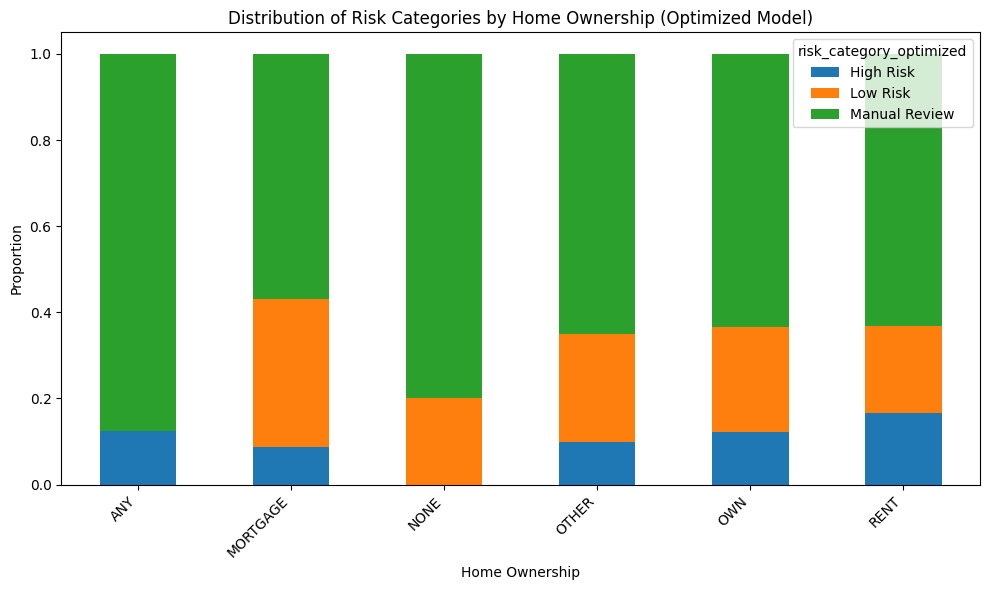

Visualizations of risk category distribution for the optimized model generated.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of risk categories for the optimized model
fig, ax = plt.subplots(figsize=(10, 6))
risk_distribution_optimized.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Distribution of Risk Categories by Home Ownership (Optimized Model)')
ax.set_xlabel('Home Ownership')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Visualizations of risk category distribution for the optimized model generated.")

## Perform Final Testing and Validation




In [60]:
y_pred_final = (y_proba_optimized >= optimal_threshold).astype(int)

print(f"Final binary predictions generated using optimal threshold ({optimal_threshold:.4f}).")

Final binary predictions generated using optimal threshold (0.6713).


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 2. Calculate the classification metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, zero_division=0)
recall_final = recall_score(y_test, y_pred_final, zero_division=0)
f1_final = f1_score(y_test, y_pred_final, zero_division=0)
roc_auc_final = roc_auc_score(y_test, y_proba_optimized)

# 3. Print all calculated metrics and compare results
print(f"\nFinal Optimized Model Performance on Test Set with Optimal Threshold ({optimal_threshold:.4f}):")
print(f"Accuracy: {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall: {recall_final:.4f}")
print(f"F1-Score: {f1_final:.4f}")
print(f"ROC AUC Score: {roc_auc_final:.4f}")

print("\n--- Comparison with Previous Models ---")
print("Initial Model (LGBM, default threshold):")
print(f"Accuracy: {accuracy_optimized:.4f} (Previous: 0.6627)")
print(f"Precision: {precision_optimized:.4f} (Previous: 0.3282)")
print(f"Recall: {recall_optimized:.4f} (Previous: 0.6783)")
print(f"F1-Score: {f1_optimized:.4f} (Previous: 0.4424)")
print(f"ROC AUC Score: {roc_auc_optimized:.4f} (Previous: 0.7335)")

print("\nOptimized Model (LGBM, previous optimal threshold):")
print(f"Accuracy: {accuracy_new:.4f}")
print(f"Precision: {precision_new:.4f}")
print(f"Recall: {recall_new:.4f}")
print(f"F1-Score: {f1_new:.4f}")
print(f"ROC AUC Score: {roc_auc_optimized:.4f} (Same as above, threshold only affects binary predictions)")


Final Optimized Model Performance on Test Set with Optimal Threshold (0.6713):
Accuracy: 0.7882
Precision: 0.4529
Recall: 0.3559
F1-Score: 0.3986
ROC AUC Score: 0.7356

--- Comparison with Previous Models ---
Initial Model (LGBM, default threshold):
Accuracy: 0.6689 (Previous: 0.6627)
Precision: 0.3324 (Previous: 0.3282)
Recall: 0.6730 (Previous: 0.6783)
F1-Score: 0.4450 (Previous: 0.4424)
ROC AUC Score: 0.7356 (Previous: 0.7335)

Optimized Model (LGBM, previous optimal threshold):
Accuracy: 0.7874
Precision: 0.4500
Recall: 0.3506
F1-Score: 0.3941
ROC AUC Score: 0.7356 (Same as above, threshold only affects binary predictions)


In [63]:
import joblib
import os


model_save_path = '/content/optimized_credit_risk_model.joblib'

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

joblib.dump(optimized_model_pipeline, model_save_path)

print(f"Optimized model saved successfully to: {model_save_path}")
print("You can download this file from the Colab file browser (left sidebar -> folder icon).")

Optimized model saved successfully to: /content/optimized_credit_risk_model.joblib
You can download this file from the Colab file browser (left sidebar -> folder icon).
